# Phenomenological Diffusion Simulations

Simulations of **240 nm bead diffusion in PEG solution** using the [AnDi challenge phenomenological library](https://github.com/AnDiChallenge/andi_datasets).  
Two models are explored: **confinement** (osmotic compartments mimicking PEG mesh regions) and **immobile traps** (transient binding to polymer entanglement sites).  
Results are compared to experimental tracking data from the `31_10_no_anomalous` dataset.

In [15]:
%pip install andi_datasets stochastic -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import sys, os, glob
import numpy as np
import matplotlib.pyplot as plt
import stochastic

from andi_datasets.models_phenom import models_phenom
from andi_datasets.utils_trajectories import plot_trajs

# Confocale/ (parent directory) contains data_reader.py and msd_analyzer.py
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from data_reader import read_trajectories_from_csv
from msd_analyzer import calculate_ensemble_msd

In [18]:
np.random.seed(42)
stochastic.random.seed(42)

# ── Physical parameters ─────────────────────────────────────────────
pixel_size = 0.1        # μm / px  (AnDi convention: 100 nm/px)
dt         = 0.04       # s / frame  (40 ms, matches experimental step)

# Stokes-Einstein: D = kT/(6πηr), 240 nm bead, ~85% glycerol/PEG, T = 298 K
D_phys = 0.007          # μm²/s

# Convert to simulation units: D [px²/frame] = D [μm²/s] × dt / pixel_size²
D_sim = D_phys * dt / pixel_size**2   # ≈ 0.028 px²/frame

# ── Trajectory parameters ──────────────────────────────────────────
T = 200          # frames per trajectory
N = 200          # number of trajectories
L = 1.5 * 128    # box side length (px) — 1.5 × 128 px field of view

print(f'D_sim    = {D_sim:.4f} px²/frame')
print(f'Box size = {L:.0f} px  =  {L * pixel_size:.1f} μm')
print(f'Duration = {T * dt:.1f} s  ({T} frames)')

# ── Helper: ensemble MSD from AnDi trajectory array ─────────────────
def compute_ensemble_msd(trajs, pixel_size, dt):
    """Initial-displacement ensemble MSD.

    Args:
        trajs      : ndarray (T, N, 2), positions in pixels
        pixel_size : float, μm per pixel
        dt         : float, seconds per frame
    Returns:
        tau (s), msd (μm²), msd_sem (μm²)
    """
    pos     = trajs * pixel_size                # (T, N, 2) in μm
    disp    = pos[1:] - pos[0:1]               # (T-1, N, 2) displacement from t=0
    sq_disp = (disp ** 2).sum(axis=2)          # (T-1, N) squared displacement
    msd     = sq_disp.mean(axis=1)
    msd_sem = sq_disp.std(axis=1, ddof=1) / np.sqrt(sq_disp.shape[1])
    tau     = np.arange(1, trajs.shape[0]) * dt
    return tau, msd, msd_sem

# Analytical free-diffusion reference (2D Brownian, α = 1)
tau_ref = np.linspace(dt, T * dt, 300)
msd_ref = 4 * D_phys * tau_ref

D_sim    = 0.0280 px²/frame
Box size = 192 px  =  19.2 μm
Duration = 8.0 s  (200 frames)


## Confinement Model

Circular compartments distributed over the field of view: particles diffuse slowly inside (`D_slow`) and quickly outside (`D_fast`); boundary transmittance `trans` controls the probability of exiting a compartment each frame.

In [19]:
Nc     = 50    # number of compartments
r_comp = 10    # compartment radius (px) = 1 μm

compartment_centers = models_phenom._distribute_circular_compartments(
    Nc=Nc, r=r_comp, L=L)

print(f'Placed {len(compartment_centers)} compartments, '
      f'radius {r_comp} px = {r_comp * pixel_size:.1f} μm')

Placed 50 compartments, radius 10 px = 1.0 μm


In [20]:
D_fast = 1500 * D_sim   # px²/frame — fast diffusion outside compartments
D_slow =   50 * D_sim   # px²/frame — slow diffusion inside compartments

trajs_conf, labels_conf = models_phenom().confinement(
    N=N, L=L, T=T,
    Ds=[D_fast, D_slow],
    alphas=[1.0, 1.0],     # non-anomalous diffusion in both states
    r=r_comp,
    trans=0.2,             # boundary transmittance
    comp_center=compartment_centers,
)
print(f'Trajectories shape: {trajs_conf.shape}  (T, N, 2)')

Trajectories shape: (200, 200, 2)  (T, N, 2)


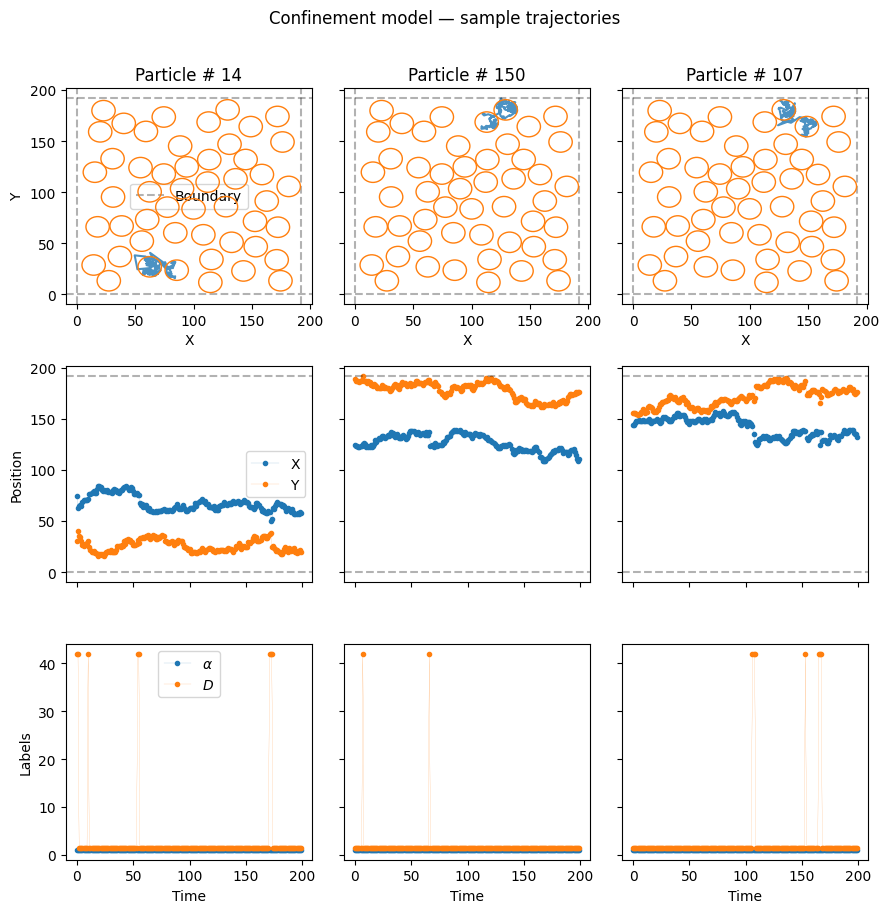

In [21]:
plot_trajs(trajs_conf, L, N,
           comp_center=compartment_centers,
           r_cercle=r_comp,
           labels=labels_conf, plot_labels=True)
plt.suptitle('Confinement model — sample trajectories', y=1.01)
plt.tight_layout()
plt.show()

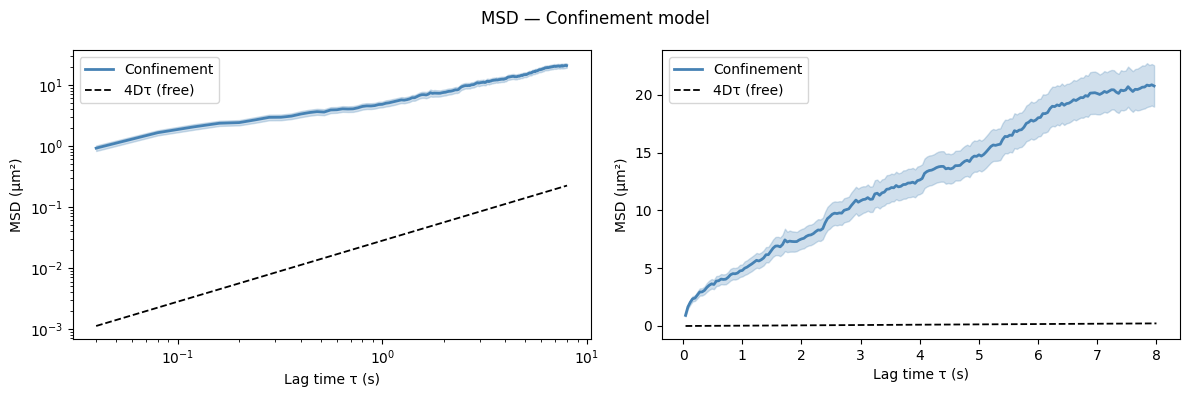

In [9]:
tau_conf, msd_conf, sem_conf = compute_ensemble_msd(trajs_conf, pixel_size, dt)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, scale in zip(axes, ['log', 'linear']):
    ax.fill_between(tau_conf, msd_conf - sem_conf, msd_conf + sem_conf,
                    alpha=0.25, color='steelblue')
    ax.plot(tau_conf, msd_conf, '-', color='steelblue', lw=2, label='Confinement')
    ax.plot(tau_ref,  msd_ref,  'k--', lw=1.3, label='4Dτ (free)')
    ax.set_xscale(scale); ax.set_yscale(scale)
    ax.set_xlabel('Lag time τ (s)')
    ax.set_ylabel('MSD (μm²)')
    ax.legend()
fig.suptitle('MSD — Confinement model')
plt.tight_layout()
plt.show()

## Immobile Traps Model

Fixed circular traps randomly distributed over the field of view: a free particle binds with probability `Pb` on contact and escapes with probability `Pu` per frame (mean trapping time ≈ 1/`Pu` frames).

In [22]:
Nt     = 100    # number of traps
r_trap = 2      # trap radius (px)
Pb     = 1.0    # binding probability when particle enters trap
Pu     = 0.01   # unbinding probability per frame  (⇒ mean trapping time ≈ 100 frames = 4 s)

trap_positions = np.random.rand(Nt, 2) * L

trajs_traps, labels_traps = models_phenom().immobile_traps(
    N=N, T=T, L=L,
    Ds=D_sim,
    alphas=1.0,
    r=r_trap,
    Pb=Pb,
    Pu=Pu,
    Nt=Nt,
    traps_pos=trap_positions,
)
print(f'Trajectories shape: {trajs_traps.shape}  (T, N, 2)')

Trajectories shape: (200, 200, 2)  (T, N, 2)


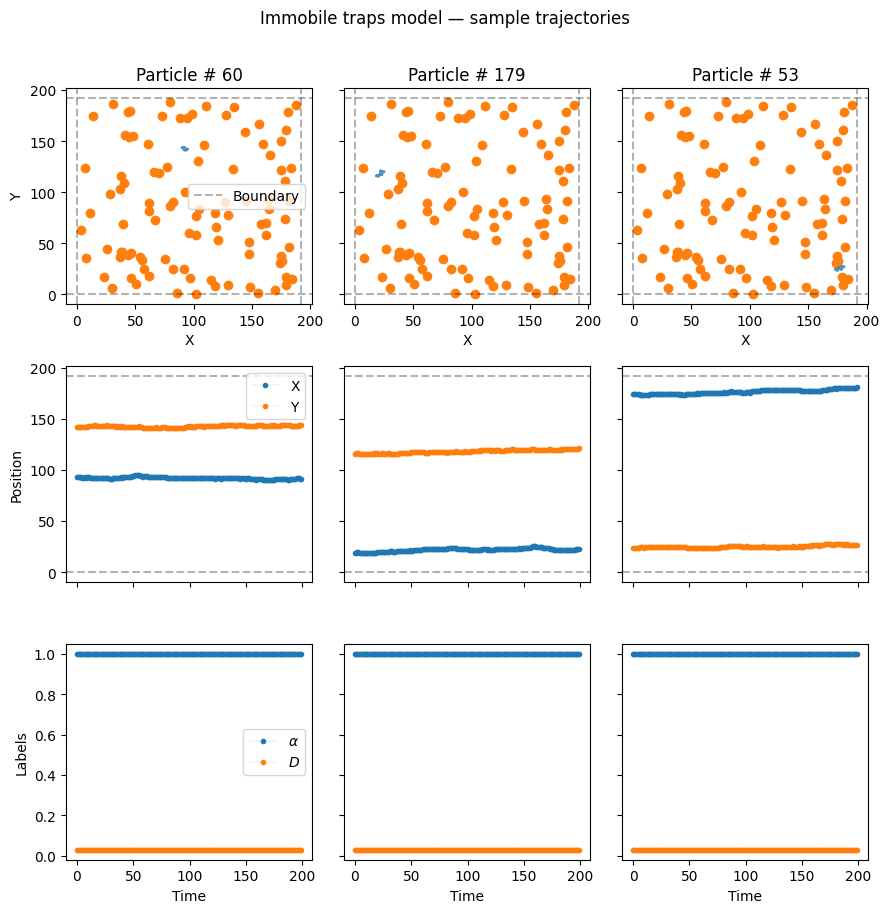

In [11]:
plot_trajs(trajs_traps, L, N,
           traps_positions=trap_positions,
           labels=labels_traps, plot_labels=True)
plt.suptitle('Immobile traps model — sample trajectories', y=1.01)
plt.tight_layout()
plt.show()

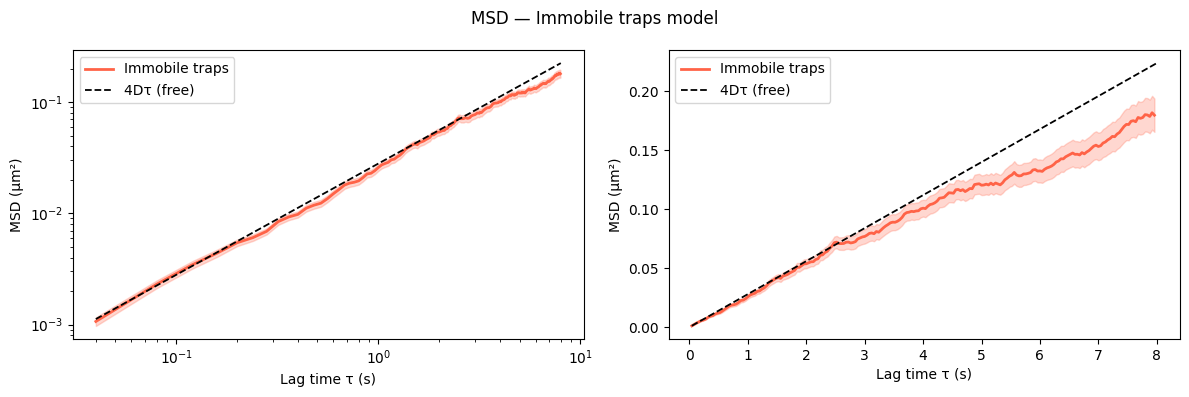

In [23]:
tau_traps, msd_traps, sem_traps = compute_ensemble_msd(trajs_traps, pixel_size, dt)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, scale in zip(axes, ['log', 'linear']):
    ax.fill_between(tau_traps, msd_traps - sem_traps, msd_traps + sem_traps,
                    alpha=0.25, color='tomato')
    ax.plot(tau_traps, msd_traps, '-', color='tomato', lw=2, label='Immobile traps')
    ax.plot(tau_ref,   msd_ref,   'k--', lw=1.3, label='4Dτ (free)')
    ax.set_xscale(scale); ax.set_yscale(scale)
    ax.set_xlabel('Lag time τ (s)')
    ax.set_ylabel('MSD (μm²)')
    ax.legend()
fig.suptitle('MSD — Immobile traps model')
plt.tight_layout()
plt.show()

## Comparison with Experimental Data

Ensemble MSD from the `31_10_no_anomalous` dataset (40 ms step files, all experiments) compared to both simulated models and the analytical free-diffusion line.

In [24]:
DATA_DIR  = os.path.join('..', 'Data', '31_10_no_anomalous')
csv_files = sorted(glob.glob(os.path.join(DATA_DIR, '*40minstep.csv')))

print(f'Loading {len(csv_files)} files (40 ms step):')
for f in csv_files:
    print(f'  {os.path.basename(f)}')

# Pool all trajectories; prefix Track ID with filename to avoid key collisions
all_trajs = {}
for fpath in csv_files:
    fname = os.path.basename(fpath)
    for tid, traj in read_trajectories_from_csv(fpath).items():
        all_trajs[f'{fname}::{tid}'] = traj

print(f'\nTotal trajectories pooled: {len(all_trajs)}')

# Ensemble MSD capped at 25 % of the longest trajectory
result_exp = calculate_ensemble_msd(all_trajs, max_lag_fraction=0.25)
tau_exp    = result_exp.tau
msd_exp    = result_exp.msd
sem_exp    = result_exp.msd_sem

print(f'Global dt = {result_exp.dt:.4f} s')
print(f'Lag range = {tau_exp[0]:.3f} – {tau_exp[-1]:.2f} s  ({result_exp.n_max} lags)')

Loading 5 files (40 ms step):
  Experiment1_spots_40minstep.csv
  Experiment2_spots_40minstep.csv
  Experiment7_spots_40minstep.csv
  Experiment8_spots_40minstep.csv
  Experiment9_spots_40minstep.csv

Total trajectories pooled: 1941
Global dt = 1.2930 s
Lag range = 1.293 – 62.06 s  (48 lags)


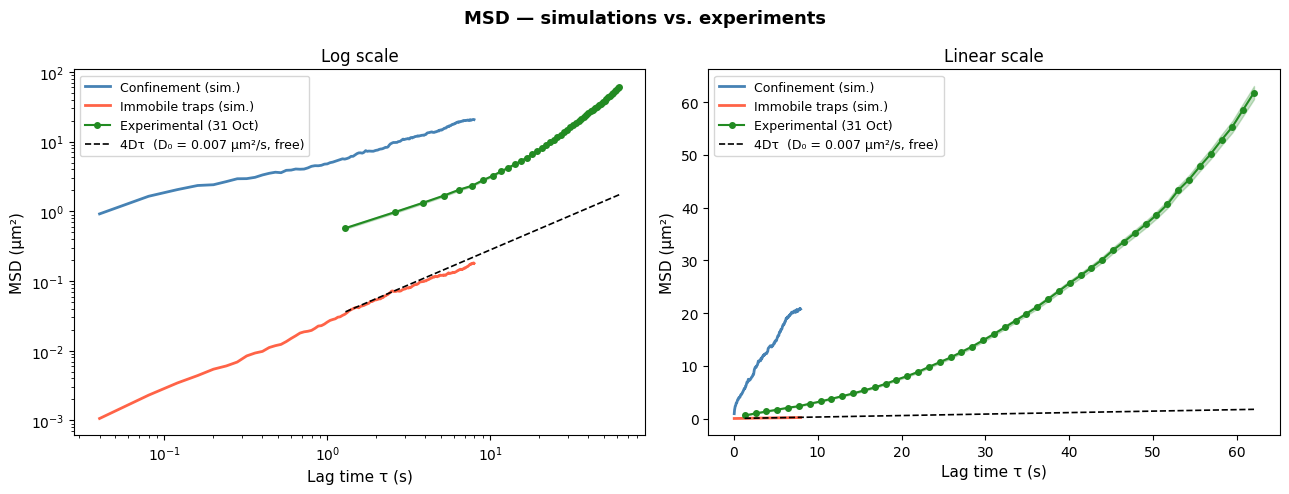

In [25]:
# Reference line over the experimental lag-time range
tau_ref_exp = np.linspace(tau_exp[0], tau_exp[-1], 300)
msd_ref_exp = 4 * D_phys * tau_ref_exp

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, scale in zip(axes, ['log', 'linear']):
    ax.plot(tau_conf,  msd_conf,  '-', color='steelblue', lw=2,
            label='Confinement (sim.)')
    ax.plot(tau_traps, msd_traps, '-', color='tomato',    lw=2,
            label='Immobile traps (sim.)')
    ax.fill_between(tau_exp, msd_exp - sem_exp, msd_exp + sem_exp,
                    alpha=0.25, color='forestgreen')
    ax.plot(tau_exp, msd_exp, 'o-', color='forestgreen', ms=4, lw=1.5,
            label='Experimental (31 Oct)')
    ax.plot(tau_ref_exp, msd_ref_exp, 'k--', lw=1.2,
            label=f'4Dτ  (D₀ = {D_phys} μm²/s, free)')
    ax.set_xscale(scale); ax.set_yscale(scale)
    ax.set_xlabel('Lag time τ (s)', fontsize=11)
    ax.set_ylabel('MSD (μm²)', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_title(f'{scale.capitalize()} scale')

fig.suptitle('MSD — simulations vs. experiments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()